In [13]:
# Cellule 1 : Imports et configuration
%load_ext autoreload
%autoreload 2

import pandas as pd

# Import du processeur de production spécialisé
from tools.OI_class_OP import OI_ProductionProcessor

# Configuration de l'affichage pour voir toutes les colonnes
pd.set_option('display.max_columns', None)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
# Cellule 2 : Définition des métadonnées de tags API
tags = [
    {'tag':'WQ33222VA', 'nom':'ester_cons','info':'Totalisation du Peson Acetate/Propionate' },
    {'tag':'3340_type', 'nom':'A/P','info':'Acetate ou Propionate' },
    {'tag':'CTY_ACV43A_Teneur Vit. A (UV)', 'nom':'Acetate_UV','info':'ACV43A teneur en acetate'},
    {'tag':'CTY_A3340FGB_Teneur arr. Vit. A (UV)', 'nom':'Propionate_UV', 'info':'A3340FGB teneur en propionate'},
    {'tag':'PU3310VA_Sign','nom':'PU3310','info':'signature du PU3310'},
    {'tag':'PU3320VA_Sign','nom':'PU3320','info':'signature du PU3320'},
    {'tag':'PU3340VA_Sign','nom':'PU3340','info':'signature du PU3340'},
    {'tag':'FQ32202VA_UV','nom':'Hexane','info':'VA diluée dans de l\'hexane'},
    {'tag':'CTY_A3230A_Teneur en rétinol', 'nom':'Retinol_UV','info':'A3230A teneur en rétinol lavé'},
    {'tag':'LI33203VA','nom':'R33020','info':'niveau du R33020'},
    {'tag':'LI33218VA','nom':'R33022','info':'niveau du R33022'},
    {'tag':'LI33225VA','nom':'R33061','info':'niveau du R33061'},
    {'tag':'WI33222VA','nom':'R33060','info':'peson du R33060'},
    {'tag':'FQ32202VA','nom':'retinol_cons','info':'peson du R33060'},
    {'tag':'LI32209VA','nom':'R32031','info':'niveau du R32031'},
]

In [15]:
# Cellule 3 : Variable Produits unifiée (Acetate & Propionate)
# Plus aucune distinction batch / continu pour le calcul global du stock d'un produit.
produits = [
    {
        'nom': 'Ester',
        'conso': {
            'value': 'ester_cons',
            'scale': 1e-9,
            'type':'A/P',
            'uv': ['Acetate_UV', 'Propionate_UV'],
        },
        'stock': [
            # Batchs
            {'pu': 'PU3310', 'in': 540, 'out': 710, 'value': 'Hexane', 'uv': 'Retinol_UV', 'scale': 1/(825 * 100.)},
            {'pu': 'PU3310', 'in': 710, 'out': 2320, 'value': None, 'uv': None, 'scale': 2.71},
            {'pu': 'PU3320', 'in': 430, 'out': 2020, 'value': None, 'uv': None, 'scale': 2.71},
            # Continus
            {'pu': None, 'value': 'R33020', 'min': 14, 'epalage': [[28.62, 21.22, 3.866, -0.0983], [-228.84, 74.557]], 'uv': 'Retinol_UV', 'scale': 1/100., 'cond':'A/P', 'val_cond':[1/344,1/359]},
            {'pu': None, 'value': 'R33022', 'min': 14, 'epalage': [[6.25, 5.4525, 0.898, -0.0256], [-35, 97, 16.039]], 'uv': 'Retinol_UV', 'scale': 1/100., 'cond':'A/P', 'val_cond':[1/344,1/359]},
            {'pu': None, 'value': 'R33061', 'min': 18, 'epalage': [[0.69, 0.72, 0.296, -0.0059], [-30.03, 5.836]], 'uv': None, 'scale': 0.95 , 'cond':'A/P', 'val_cond':[1/344,1/359]},
            {'pu': 'PU3340', 'in': 0, 'out': 710, 'value': 'R33060', 'uv': None, 'scale': 0.95, 'cond': 'A/P', 'val_cond': [1/344, 1/359]}
        ]
    },
    {
        'nom': 'Retinol',
        'conso': {
            'value':'retinol_cons',
            'scale': 1e-5, # Ajustement de l'échelle pour le retinol g et analyse en %
            'uv': ['Retinol_UV','Retinol_UV'],
        },
        'stock': [
            # Batchs
            {'pu': None, 'value': 'R32031', 'uv': 'Retinol_UV', 'scale': 1/(825 * 100.)},
        ]
    }
]

In [16]:
# Cellule 4 : Initialisation du processeur de production spécialisé
processor = OI_ProductionProcessor(
    url_base = 'https://oianalytics-100.optimistik.fr/api/oianalytics/time-values/query?',
    start = '2026-01-01',
    end = '2026-12-31',
    tags_metadata = tags,
    produits = produits,
    interval = 'PT20M',
    verbose = False
)

In [17]:
# Cellule 5 : Téléchargement et calcul automatique des bilans par produit
processor.merge()
processor.compute_production_balance()

# Visualisation des premières lignes calculées
processor.data.describe()

,ester_cons,A/P,Acetate_UV,Propionate_UV,PU3310,PU3320,PU3340,Hexane,Retinol_UV,R33020,R33022,R33061,R33060,retinol_cons,R32031,consommation_Ester,stock_Ester,consommation_Retinol,stock_Retinol,conso_delta_Ester,delta_stock_Ester,production_Ester,conso_delta_Retinol,delta_stock_Retinol,production_Retinol
count,1.082700e+04,10827.000000,1.082700e+04,1.082700e+04,10824.000000,10825.000000,10823.000000,10827.000000,10827.000000,10827.000000,10827.000000,10827.000000,10827.000000,10827.000000,10827.000000,10827.000000,10827.000000,10827.000000,10827.000000,10827.000000,10827.000000,10827.000000,10827.000000,10827.000000,10827.000000
mean,2.448006e+06,0.076800,2.226178e+06,2.281977e+06,1012.545869,941.540079,461.835830,2562.164531,20.790678,45.608269,4.971260,7.200055,685.224731,460687.312739,47.635103,505.164188,6.657511,387623.872805,0.012003,505.164188,0.430099,505.594287,387623.872805,-0.002166,387623.870639
std,1.418156e+05,0.266159,3.872272e+04,5.075013e+04,598.854580,529.427132,111.508220,1862.979433,0.371068,20.353855,2.411416,10.987567,345.165153,251280.583352,20.445127,317.293107,2.252555,485881.872854,0.005155,317.293107,2.252555,317.835393,485881.872854,0.005155,485881.873131
min,2.221310e+06,0.000000,2.078915e+06,2.188000e+06,100.000000,100.000000,313.116667,0.000000,20.000000,-7.918751,-0.695313,-0.337315,6.278194,640.456000,0.220855,0.000000,0.724677,0.000000,0.000056,0.000000,-5.502735,-1.516407,0.000000,-0.014113,0.000000
25%,2.313580e+06,0.000000,2.221983e+06,2.242000e+06,400.000000,400.000000,410.000000,0.000000,20.600000,24.036780,3.600138,2.207722,426.115517,247246.000000,39.774340,204.811540,5.519558,64.534966,0.010013,204.811540,-0.707854,206.016545,64.534966,-0.004157,64.532448
50%,2.431310e+06,0.000000,2.231260e+06,2.314000e+06,1309.412500,1113.683333,410.000000,3932.160000,20.800000,44.902719,5.945736,2.941349,682.271038,425802.537500,45.008120,465.981104,7.028826,148.153046,0.011509,465.981104,0.801413,470.798248,148.153046,-0.002660,148.140786
75%,2.571380e+06,0.000000,2.245049e+06,2.314000e+06,1310.000000,1297.683333,410.000000,4036.910000,21.200000,64.485178,6.503910,4.112852,940.679865,664132.000000,66.810812,781.080079,8.168369,996790.445444,0.016762,781.080079,1.940956,782.957004,996790.445444,0.002592,996790.442804
max,2.708300e+06,1.000000,2.325113e+06,2.626000e+06,2320.033333,2249.987500,810.000000,4836.070000,21.200000,91.504357,12.239069,68.457970,1321.036235,997389.108434,79.734400,1089.718207,12.528535,996883.331773,0.019909,1089.718207,6.301123,1093.221466,996883.331773,0.005740,996883.335441


In [18]:
processor.data.loc[:, ['retinol_cons']][101:174]
m=(126816.000-114647.000)/1000*20*30/100
m

73.014

In [19]:
# Cellule 6 : Calcul du bilan mensuel général (ex: Mai 2026 à date)
bilan = processor.calcul_cumul_mensuel(mois=5, std=2)

____________________________________________________________
BILAN MENSUEL - MAI 2026 (À date (En cours))
Période : du 01/05/2026 à 02:00 au 31/05/2026 à 12:40
____________________________________________________________
PRODUIT : ESTER
------------------------------------------------------------
  Consommation (Ester)   : 258.3815
  Variation de Stock     : -2.1119
  Production             : 256.2696
____________________________________________________________
PRODUIT : RETINOL
------------------------------------------------------------
  Consommation (Ester)   : 77.4556
  Variation de Stock     : 0.0111
  Production             : 77.4668
____________________________________________________________
____________________________________________________________


In [20]:
# Cellule 6 : Calcul du bilan mensuel général (ex: Mai 2026 à date)
bilan = processor.calcul_cumul_mensuel(mois=5, std=2)

____________________________________________________________
BILAN MENSUEL - MAI 2026 (À date (En cours))
Période : du 01/05/2026 à 02:00 au 31/05/2026 à 12:40
____________________________________________________________
PRODUIT : ESTER
------------------------------------------------------------
  Consommation (Ester)   : 258.3815
  Variation de Stock     : -2.1119
  Production             : 256.2696
____________________________________________________________
PRODUIT : RETINOL
------------------------------------------------------------
  Consommation (Ester)   : 77.4556
  Variation de Stock     : 0.0111
  Production             : 77.4668
____________________________________________________________
____________________________________________________________


In [21]:
# Cellule 6 : Calcul du bilan mensuel général (ex: Mai 2026 à date)
bilan = processor.calcul_cumul_mensuel(mois=5, std=2)

____________________________________________________________
BILAN MENSUEL - MAI 2026 (À date (En cours))
Période : du 01/05/2026 à 02:00 au 31/05/2026 à 12:40
____________________________________________________________
PRODUIT : ESTER
------------------------------------------------------------
  Consommation (Ester)   : 258.3815
  Variation de Stock     : -2.1119
  Production             : 256.2696
____________________________________________________________
PRODUIT : RETINOL
------------------------------------------------------------
  Consommation (Ester)   : 77.4556
  Variation de Stock     : 0.0111
  Production             : 77.4668
____________________________________________________________
____________________________________________________________


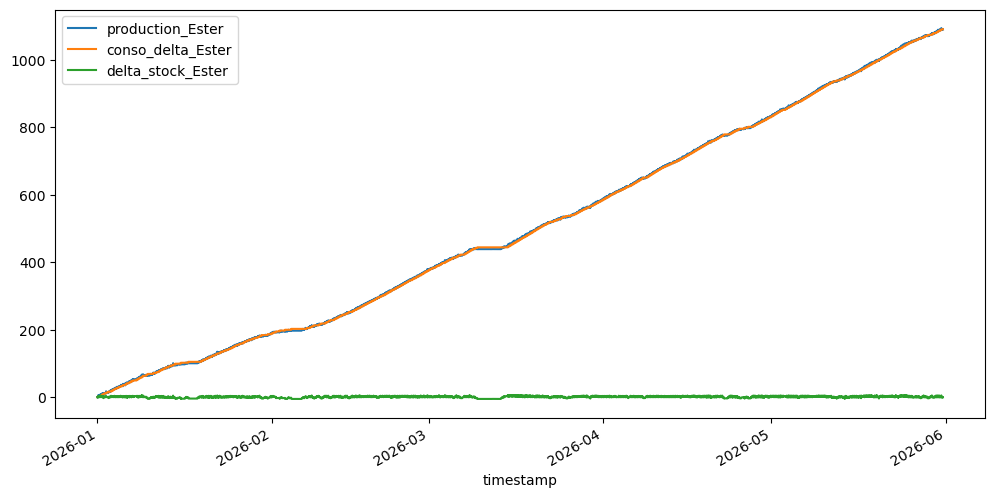

In [22]:
# Cellule 7 : Graphique temporel du bilan d'Acétate
processor.data.plot(y=['production_Ester', 'conso_delta_Ester', 'delta_stock_Ester'], figsize=(12,6));

In [23]:
# Cellule 6 : Calcul du bilan mensuel général (ex: Mai 2026 à date)
bilan = processor.calcul_cumul_journalier(jour=31, mois=5, std=2)
#print(bilan)

____________________________________________________________
BILAN JOURNALIER - 31 MAI 2026 (À date (En cours))
Période : du 31/05/2026 à 02:00 au 31/05/2026 à 12:40
____________________________________________________________
PRODUIT : ESTER
------------------------------------------------------------
  Consommation (Ester)   : 2.8114
  Variation de Stock     : -3.0697
  Production             : -0.2583
____________________________________________________________
PRODUIT : RETINOL
------------------------------------------------------------
  Consommation (Ester)   : 0.0000
  Variation de Stock     : 0.0053
  Production             : 0.0053
____________________________________________________________
____________________________________________________________
